First, transforming a periodic signal (**e.g. sinusoidal signal**)

In [52]:
import math
import numpy as np
import matplotlib.pyplot as plt

period = 2*np.pi
def func(x):
    return np.sin(x)

def integration(x,y):
    somme=0
    for i in range(0,len(x)-2,2):
        somme+=((x[1]-x[0])*(y[i]+4*y[i+1]+y[i+2]))/3
    return somme

x_axis= np.linspace(0,2*np.pi,1001) #toujours mettre un nombre de points impaire
y_axis = func(x_axis)
"""
plt.grid(True, linestyle='--', color='gray', alpha=0.5)
plt.plot(x_axis,y_axis)
plt.title('Signal form')
plt.show()
somme=integration(x_axis,y_axis)
print(somme)
"""

"\nplt.grid(True, linestyle='--', color='gray', alpha=0.5)\nplt.plot(x_axis,y_axis)\nplt.title('Signal form')\nplt.show()\nsomme=integration(x_axis,y_axis)\nprint(somme)\n"

In [66]:

FC=[]

def sig_to_coeff(x,y,N):
    w0=2*np.pi/period
    Coeff=[]
    y0 = y * np.exp(0)   # e^0 = 1 donc y0 = y
    C0 = 1/period * integration(x, y0)
    for k in range(1,N+1):
        yk=y*np.exp(-1j*k*w0*x)
        Ck=1/period*integration(x,yk)
        Coeff.append(Ck)
    return C0,Coeff


N=10
C0,FC=sig_to_coeff(x_axis,y_axis,N)
modules=np.concatenate([np.flip(np.abs(FC)),[np.abs(C0)],np.abs(FC)])
arguments=np.concatenate([np.flip(-np.angle(FC)),[np.angle(C0)],np.angle(FC)])
seuil = 1e-6
arguments[modules < seuil] = 0

Then, showing module and argument of calculated coefficients

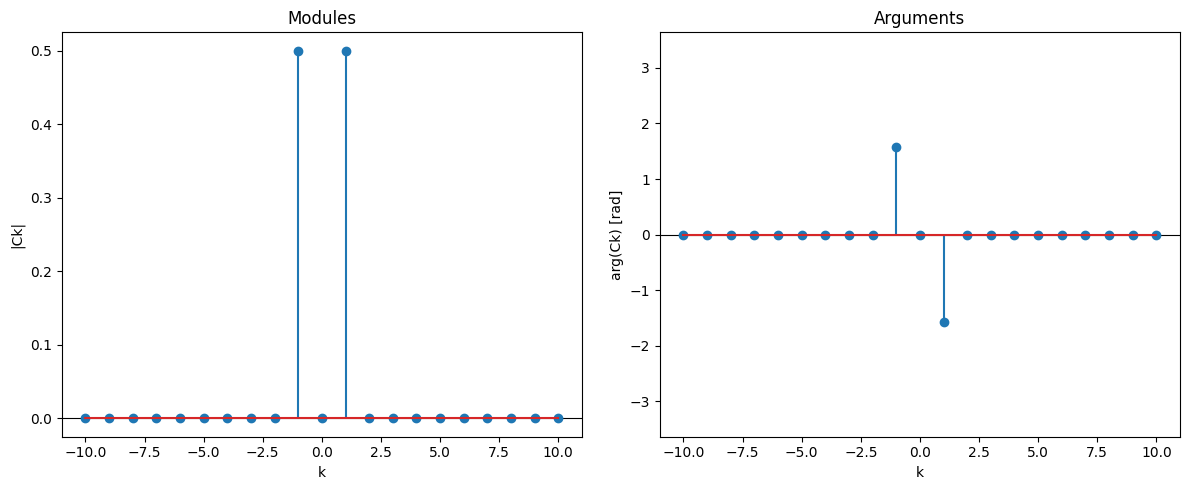

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.axhline(y=0, color='k', linewidth=0.8)
ax2.axhline(y=0, color='k', linewidth=0.8)
ax1.set_xlabel('k')
ax1.set_ylabel('|Ck|')
ax2.set_xlabel('k')
ax2.set_ylabel('arg(Ck) [rad]')
ax1.stem(np.arange(-N,N+1),modules)
ax2.stem(np.arange(-N,N+1),arguments)
ax1.set_title('Modules')
ax2.set_title('Arguments')
plt.tight_layout()
ax2.set_ylim(-np.pi - 0.5, np.pi + 0.5)


plt.show()